In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


df = pd.read_csv('Pizza reviews.csv')

print(f"SHAPE\n{df.shape}")
print(f"INFO\n{df.info}")
print(f"DESCRIBE\n{df.describe()}")

print(f"Sum of missing values:{df.isna().sum()}")

SHAPE
(902, 4)
INFO
<bound method DataFrame.info of                                                 Review     Score  \
0                                          Disgusting.         1   
1                               Loved the sambal kick!        10   
2                               Loved the sambal kick!       0.1   
3                               Loved the sambal kick!         5   
4    Satay on pizza? Surprisingly worked. Tasty, un...         7   
..                                                 ...       ...   
897                                             Ni hao       NaN   
898                              Hen tai fei chang hao     0.001   
899                                          Nani kore  0.997413   
900                                           Diabolic       NaN   
901                                               Jia!       ???   

    Are there ways for you to generate more data? Spliting up sentences, would that help?  \
0                                     

In [2]:
print("Duplicate rows:", df.duplicated().sum())

duplicates = df[df.duplicated()]
print(duplicates.head())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 45
                                               Review Score  \
17  The sambal slice burned my mouth in the best w...     8   
23                Sambal overwhelmed everything else.     4   
24  Satay chicken worked well on pizza. Creative b...     6   
25      Enjoyed every bite, especially the satay one.     8   
26                                        Disgusting.     2   

   Are there ways for you to generate more data? Spliting up sentences, would that help?  \
17                                                NaN                                      
23                                                NaN                                      
24                                                NaN                                      
25                                                NaN                                      
26                                                NaN                                      

   Language  
17  English  
23  English  
24  Eng

In [3]:
print(df.isnull().sum())

df = df.drop(columns=["Are there ways for you to generate more data? Spliting up sentences, would that help?"])

df = df.dropna(subset=["Review"])

print(df.isnull().sum())

Review                                                                                     0
Score                                                                                      2
Are there ways for you to generate more data? Spliting up sentences, would that help?    855
Language                                                                                   0
dtype: int64
Review      0
Score       2
Language    0
dtype: int64


In [4]:
df = df.dropna(subset=["Score"])

print(df["Score"].isna().sum())


0


In [5]:
print(df["Score"].min())
print(df["Score"].max())

-0.05
Score


Language
English                      473
Malay                        375
Guga                           2
Chinese                        2
Come on ...                    1
You cannot be serious ...      1
Nippon                         1
Name: count, dtype: int64


C:\Users\JunHao\AppData\Local\Temp\ipykernel_16820\3447723401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


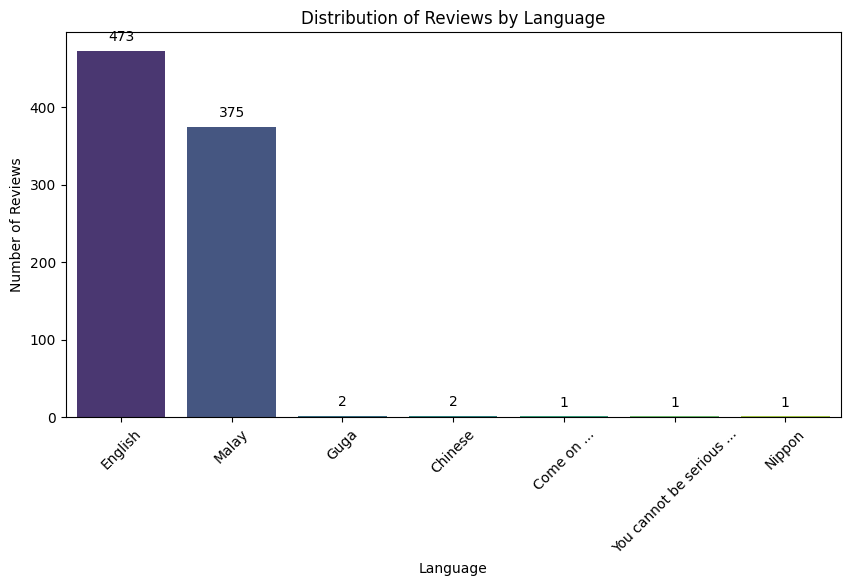

In [6]:
print(df["Language"].value_counts())

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Language",
    order=df["Language"].value_counts().index,
    palette="viridis"
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.title("Distribution of Reviews by Language")
plt.xlabel("Language")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

plt.show()

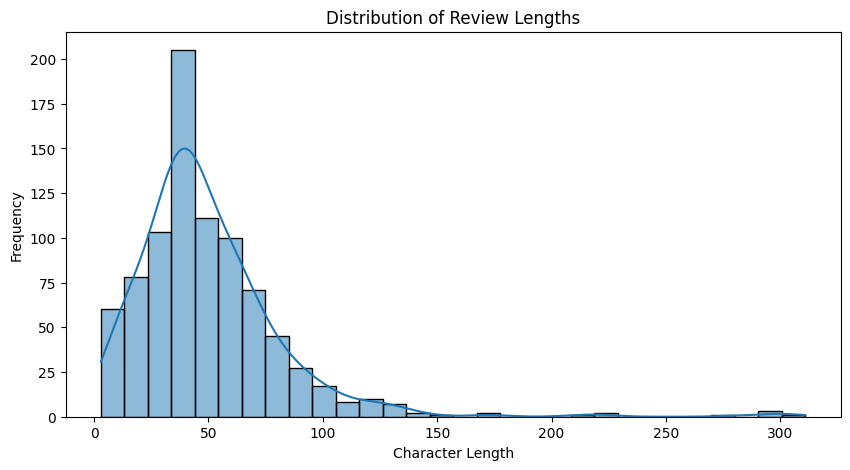

In [7]:
df["review_length"] = df["Review"].astype(str).apply(len)

plt.figure(figsize=(10,5))

sns.histplot(df["review_length"], bins=30, kde=True)

plt.title("Distribution of Review Lengths")
plt.xlabel("Character Length")
plt.ylabel("Frequency")

plt.show()

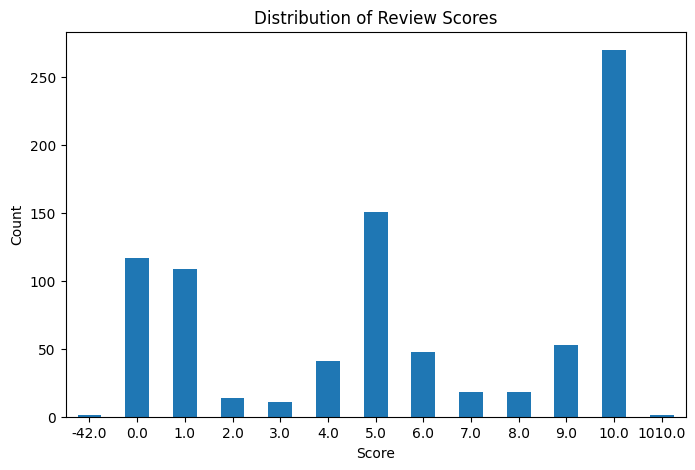

In [8]:
# Convert Score to numeric
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

# Optional: round score to nearest whole number
df['Score_Rounded'] = df['Score'].round()

# Plot neatly
plt.figure(figsize=(8,5))
df['Score_Rounded'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

df = df.dropna(subset=["Score"])

df = df[(df["Score"] >= 0) & (df["Score"] <= 10)]

valid_languages = ["English", "Malay"]

df = df[df["Language"].isin(valid_languages)]

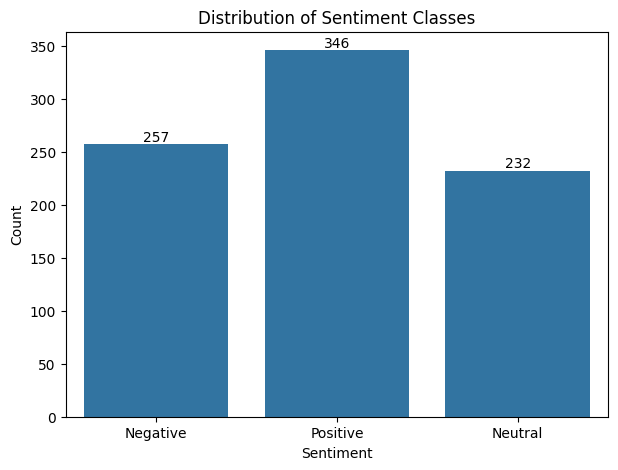

In [10]:
def sentiment_label(score):
    if score <= 4:
        return "Negative"
    elif score <= 7:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment_label)

plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="Sentiment")

ax.bar_label(ax.containers[0])

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Feature Engineering

Stopwords were retained because sequence-based models such as RNNs benefit from contextual information. Removing stopwords such as “not” may negatively affect sentiment interpretation.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = text.replace("’", "'")
    text = text.replace("didn't", "did not")
    text = text.replace("can't", "cannot")
    text = text.replace("won't", "will not")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_review"] = df["Review"].apply(clean_text)

# Tokenizer

In [ ]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["clean_review"])

sequences = tokenizer.texts_to_sequences(df["clean_review"])

X = pad_sequences(sequences, maxlen=100)

# Encode Labels

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["Sentiment"])

# Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
comparison_df = pd.DataFrame({
    "Original Review": df["Review"].head(10),
    "Cleaned Review": df["clean_review"].head(10)
})

comparison_df

,Original Review,Cleaned Review
0,Disgusting.,disgusting
1,Loved the sambal kick!,loved the sambal kick
2,Loved the sambal kick!,loved the sambal kick
3,Loved the sambal kick!,loved the sambal kick
4,"Satay on pizza? Surprisingly worked. Tasty, un...",satay on pizza surprisingly worked tasty uniqu...
5,Mayo was too sweet. Didn't enjoy it at all.,mayo was too sweet did not enjoy it at all
6,"Spicy sambal was overwhelming for me, but the ...",spicy sambal was overwhelming for me but the s...
7,"Crust was soggy, and the satay sauce didn’t he...",crust was soggy and the satay sauce did not he...
8,Super creative! Sambal slice was fiery and bol...,super creative sambal slice was fiery and bold...
9,The sambal slice burned my mouth in the best w...,the sambal slice burned my mouth in the best w...


In [25]:
print("Original Review:")
print(df["clean_review"].iloc[0])

print("\nTokenized Sequence:")
print(sequences[0])

Original Review:
disgusting

Tokenized Sequence:
[170]


In [26]:
print("Sequence before padding:")
print(sequences[0])

print("\nLength before padding:")
print(len(sequences[0]))

print("\nSequence after padding:")
print(X[0])

print("\nLength after padding:")
print(len(X[0]))

Sequence before padding:
[170]

Length before padding:
1

Sequence after padding:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0 170]

Length after padding:
100


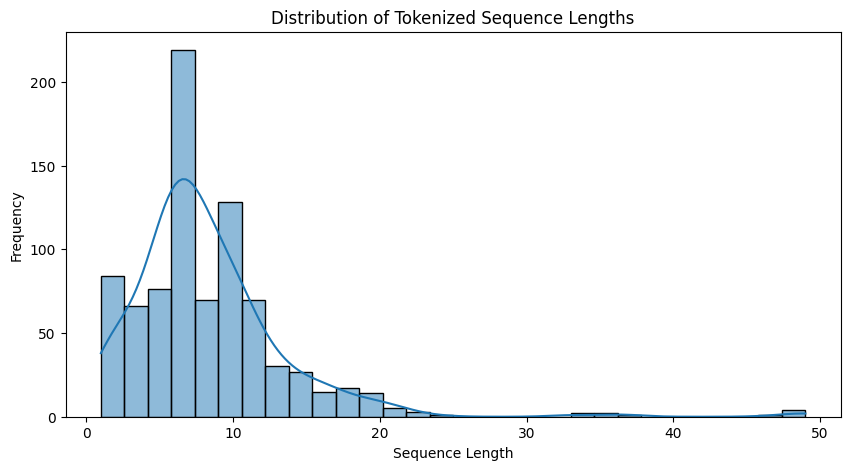

In [27]:
sequence_lengths = [len(seq) for seq in sequences]

plt.figure(figsize=(10,5))

sns.histplot(sequence_lengths, bins=30, kde=True)

plt.title("Distribution of Tokenized Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

plt.show()

Vocabulary Size: 854
[('pizza', 286), ('the', 231), ('dan', 206), ('rasa', 194), ('and', 186), ('sambal', 180), ('was', 165), ('fusion', 157), ('mayo', 146), ('sangat', 122)]


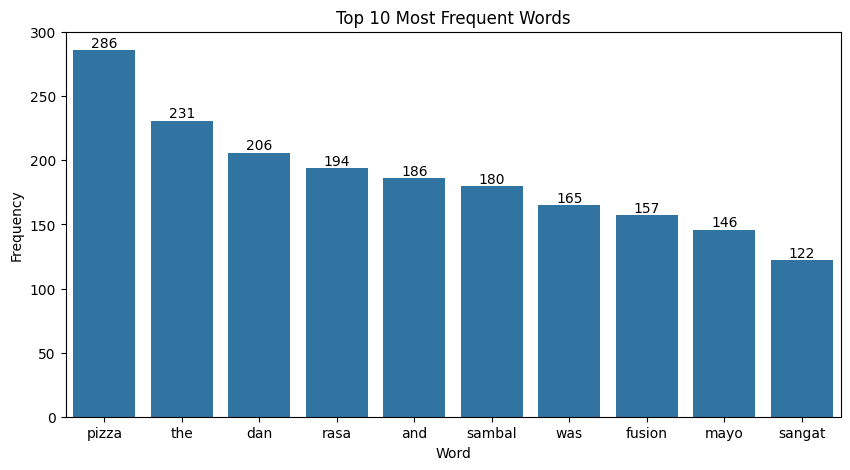

In [28]:
print("Vocabulary Size:", len(tokenizer.word_index))

word_counts = tokenizer.word_counts

top_words = sorted(
    word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print(top_words)

top_words_df = pd.DataFrame(top_words, columns=["Word", "Count"])

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_words_df,
    x="Word",
    y="Count"
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

# Simple RNN

In [30]:
vocab_size = 5000
max_len = 100
embedding_dim = 64

simple_rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    SimpleRNN(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

simple_rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

simple_rnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 64)                8256      
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 3)                 99        
                                                                 
Total params: 330,435
Trainable params: 330,435
Non-trainable params: 0
_________________________________________________________________


In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = simple_rnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

rnn_loss, rnn_acc = simple_rnn_model.evaluate(X_test, y_test)

print("SimpleRNN Accuracy:", rnn_acc)

Epoch 1/15
17/17 [==============================] - 2s 44ms/step - loss: 1.0899 - accuracy: 0.4064 - val_loss: 1.0181 - val_accuracy: 0.5672
Epoch 2/15
17/17 [==============================] - 0s 22ms/step - loss: 0.9328 - accuracy: 0.6180 - val_loss: 0.8580 - val_accuracy: 0.6269
Epoch 3/15
17/17 [==============================] - 0s 23ms/step - loss: 0.7653 - accuracy: 0.6704 - val_loss: 0.7650 - val_accuracy: 0.6493
Epoch 4/15
17/17 [==============================] - 0s 23ms/step - loss: 0.6403 - accuracy: 0.7378 - val_loss: 0.7717 - val_accuracy: 0.6866
Epoch 5/15
17/17 [==============================] - 0s 22ms/step - loss: 0.5217 - accuracy: 0.8670 - val_loss: 0.6406 - val_accuracy: 0.7910
Epoch 6/15
17/17 [==============================] - 0s 22ms/step - loss: 0.3491 - accuracy: 0.9101 - val_loss: 0.5651 - val_accuracy: 0.7985
Epoch 7/15
17/17 [==============================] - 0s 24ms/step - loss: 0.2260 - accuracy: 0.9363 - val_loss: 0.5520 - val_accuracy: 0.8060
Epoch 8/15
17

In [32]:
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)

Epoch 1/15
17/17 [==============================] - 5s 179ms/step - loss: 1.0826 - accuracy: 0.4476 - val_loss: 1.0498 - val_accuracy: 0.4776
Epoch 2/15
17/17 [==============================] - 2s 106ms/step - loss: 0.9736 - accuracy: 0.5506 - val_loss: 0.8695 - val_accuracy: 0.6194
Epoch 3/15
17/17 [==============================] - 1s 78ms/step - loss: 0.8111 - accuracy: 0.6180 - val_loss: 0.7419 - val_accuracy: 0.7015
Epoch 4/15
17/17 [==============================] - 1s 58ms/step - loss: 0.6746 - accuracy: 0.6648 - val_loss: 0.6175 - val_accuracy: 0.7090
Epoch 5/15
17/17 [==============================] - 1s 74ms/step - loss: 0.5575 - accuracy: 0.7416 - val_loss: 0.5579 - val_accuracy: 0.8209
Epoch 6/15
17/17 [==============================] - 2s 100ms/step - loss: 0.4510 - accuracy: 0.8596 - val_loss: 0.4576 - val_accuracy: 0.8657
Epoch 7/15
17/17 [==============================] - 1s 61ms/step - loss: 0.3123 - accuracy: 0.9064 - val_loss: 0.4645 - val_accuracy: 0.8433
Epoch 8/15

In [33]:
gru_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),

    GRU(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print("GRU Accuracy:", gru_acc)

Epoch 1/15
17/17 [==============================] - 5s 99ms/step - loss: 1.0862 - accuracy: 0.4195 - val_loss: 1.0668 - val_accuracy: 0.3881
Epoch 2/15
17/17 [==============================] - 1s 49ms/step - loss: 0.9980 - accuracy: 0.5131 - val_loss: 0.9107 - val_accuracy: 0.6567
Epoch 3/15
17/17 [==============================] - 1s 70ms/step - loss: 0.7720 - accuracy: 0.7566 - val_loss: 0.6683 - val_accuracy: 0.7836
Epoch 4/15
17/17 [==============================] - 1s 67ms/step - loss: 0.5433 - accuracy: 0.8839 - val_loss: 0.5340 - val_accuracy: 0.8134
Epoch 5/15
17/17 [==============================] - 2s 99ms/step - loss: 0.3473 - accuracy: 0.8951 - val_loss: 0.4765 - val_accuracy: 0.8433
Epoch 6/15
17/17 [==============================] - 2s 100ms/step - loss: 0.1979 - accuracy: 0.9307 - val_loss: 0.5061 - val_accuracy: 0.8284
Epoch 7/15
17/17 [==============================] - 1s 56ms/step - loss: 0.1190 - accuracy: 0.9588 - val_loss: 0.5649 - val_accuracy: 0.8358
Epoch 8/15
6

In [34]:
results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    "Accuracy": [rnn_acc, lstm_acc, gru_acc]
})

results

,Model,Accuracy
0,SimpleRNN,0.820359
1,LSTM,0.874251
2,GRU,0.790419


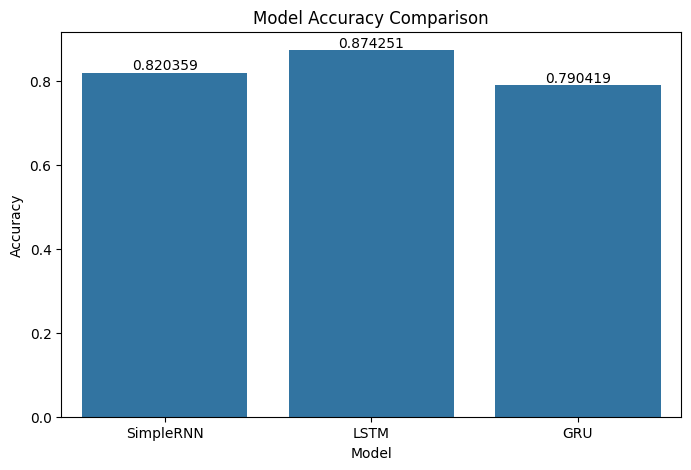

In [35]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

ax.bar_label(ax.containers[0])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# Model Improvement

## 1. Dropout

## 2. Bidirectional LSTM

## 3. Increase Embedding Size

## 4. Add more epochs + early stopping

## 5. Data Augmentation

In [39]:
# Parameters
vocab_size = 5000
embedding_dim = 128
max_len = 100

# Improved model
improved_lstm = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    ),

    Bidirectional(
        LSTM(64, return_sequences=False)
    ),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
])

# Compile
improved_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
improved_lstm.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 100, 128)          640000    
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              98816     
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_8 (Dense)             (None, 32)                4128      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_9 (Dense)             (None, 3)                 99        
                                                      

1. Bidirectional LSTM
Bidirectional(LSTM(64))

Allows the model to:

read sequences forward
AND backward

Example:

"not good"

Backward context helps sentiment understanding.

This is a strong NLP improvement.

2. Larger Embedding Dimension
embedding_dim = 128

Improves semantic representation of words.

Baseline:

64

Improved:

128
3. Dropout
Dropout(0.5)

Helps reduce overfitting.

Very important because the dataset is small.

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_improved = improved_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
17/17 [==============================] - 9s 232ms/step - loss: 1.0866 - accuracy: 0.4139 - val_loss: 1.0679 - val_accuracy: 0.3881
Epoch 2/20
17/17 [==============================] - 2s 146ms/step - loss: 1.0551 - accuracy: 0.4888 - val_loss: 0.9948 - val_accuracy: 0.5970
Epoch 3/20
17/17 [==============================] - 2s 105ms/step - loss: 0.9458 - accuracy: 0.5861 - val_loss: 0.8227 - val_accuracy: 0.6269
Epoch 4/20
17/17 [==============================] - 1s 76ms/step - loss: 0.7378 - accuracy: 0.7097 - val_loss: 0.6101 - val_accuracy: 0.8433
Epoch 5/20
17/17 [==============================] - 1s 74ms/step - loss: 0.5157 - accuracy: 0.8221 - val_loss: 0.4377 - val_accuracy: 0.8433
Epoch 6/20
17/17 [==============================] - 1s 73ms/step - loss: 0.3733 - accuracy: 0.8596 - val_loss: 0.4671 - val_accuracy: 0.8507
Epoch 7/20
17/17 [==============================] - 1s 75ms/step - loss: 0.2537 - accuracy: 0.9288 - val_loss: 0.4849 - val_accuracy: 0.8134
Epoch 8/20

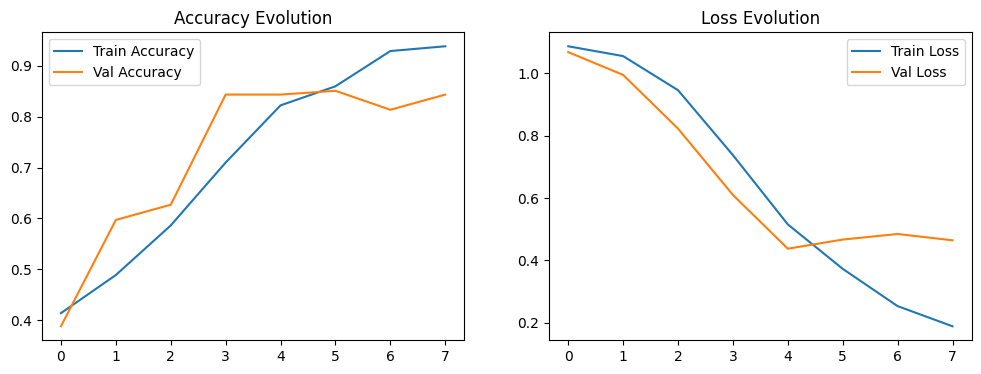

In [41]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()